# 🏥 Diabetes Hospital Readmission

## Phase 1 — Business Understanding

The objective of this project is to analyze hospital encounters of patients with diabetes and develop a machine learning model to identify patients at risk of hospital readmission.

The project follows the CRISP-DM methodology:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

### Business Question

Can we use information available from a patient's hospital encounter to identify patients who are at higher risk of being readmitted?

### Target

The dataset contains a `readmitted` variable with three possible outcomes:

- `<30` — patient was readmitted within 30 days
- `>30` — patient was readmitted after 30 days
- `NO` — patient was not readmitted

In [100]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mramirasgari/diabetes-130-us-hospitals-readmission/IDS_mapping.csv
/kaggle/input/datasets/mramirasgari/diabetes-130-us-hospitals-readmission/diabetic_data.csv


In [101]:
data_path = "/kaggle/input/datasets/mramirasgari/diabetes-130-us-hospitals-readmission/diabetic_data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Data Mining Goal

The modeling task will be formulated as a **binary classification problem** focused on early hospital readmission.

The original `readmitted` variable contains three categories:

- `<30` — readmitted within 30 days
- `>30` — readmitted after 30 days
- `NO` — no recorded readmission

For the predictive task:

- **Positive class (1):** readmitted within 30 days (`<30`)
- **Negative class (0):** readmitted after 30 days or not readmitted (`>30` or `NO`)

The main objective is to identify patients at risk of **early readmission**.

### Evaluation Goal

Because missing a high-risk patient may be more important than producing a small number of additional false alarms, model evaluation will focus primarily on:

- Recall
- Precision
- F1 Score
- PR-AUC

Accuracy will not be used as the primary evaluation metric.

In [102]:
readmission_counts = df["readmitted"].value_counts()
readmission_percentages = df["readmitted"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": readmission_counts,
    "Percentage": readmission_percentages.round(2)
})

target_summary

,Count,Percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


### 2.1 Target Distribution

The early-readmission class (`<30`) represents only **11.16%** of all hospital encounters.

After converting the problem to binary classification:

- **Positive class:** `<30` → 11.16%
- **Negative class:** `NO` or `>30` → 88.84%

This confirms a substantial class imbalance. Therefore, overall accuracy alone may provide a misleading view of model performance.

In [103]:
column_summary = []

for column in df.columns:
    question_mark_count = 0

    if df[column].dtype == "object":
        question_mark_count = (df[column] == "?").sum()

    column_summary.append({
        "Column": column,
        "Data Type": str(df[column].dtype),
        "Unique Values": df[column].nunique(dropna=False),
        "Missing (NaN)": df[column].isna().sum(),
        "Missing (?)": question_mark_count
    })

column_summary = pd.DataFrame(column_summary)

column_summary

,Column,Data Type,Unique Values,Missing (NaN),Missing (?)
0,encounter_id,int64,101766,0,0
1,patient_nbr,int64,71518,0,0
2,race,object,6,0,2273
3,gender,object,3,0,0
4,age,object,10,0,0
5,weight,object,10,0,98569
6,admission_type_id,int64,8,0,0
7,discharge_disposition_id,int64,26,0,0
8,admission_source_id,int64,17,0,0
9,time_in_hospital,int64,14,0,0


### 2.2 Column Structure and Missing Data

The dataset contains a mixture of numerical, categorical, identifier, diagnostic, and medication-related variables.

Several important observations were identified:

- `encounter_id` is unique for each hospital encounter.
- `patient_nbr` has fewer unique values than the number of encounters, indicating that some patients appear multiple times in the dataset.
- Several variables contain substantial missing information, particularly `weight`, `payer_code`, `medical_specialty`, `max_glu_serum`, and `A1Cresult`.
- Missing information is represented in two different ways: standard `NaN` values and the string `"?"`.

No variables will be removed at this stage. Missingness will first be quantified and interpreted before preprocessing decisions are made.

In [104]:
nan_missing = df.isna().sum()

question_missing = pd.Series(
    {
        column: (df[column] == "?").sum()
        if df[column].dtype == "object"
        else 0
        for column in df.columns
    }
)

total_missing = nan_missing + question_missing

missing_summary = pd.DataFrame({
    "NaN Missing": nan_missing,
    "? Missing": question_missing,
    "Total Missing": total_missing,
    "Missing Percentage": (total_missing / len(df) * 100).round(2)
})

missing_summary = (
    missing_summary[missing_summary["Total Missing"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)

missing_summary

,NaN Missing,? Missing,Total Missing,Missing Percentage
weight,0,98569,98569,96.86
max_glu_serum,96420,0,96420,94.75
A1Cresult,84748,0,84748,83.28
medical_specialty,0,49949,49949,49.08
payer_code,0,40256,40256,39.56
race,0,2273,2273,2.23
diag_3,0,1423,1423,1.40
diag_2,0,358,358,0.35
diag_1,0,21,21,0.02


### 2.3 Missing Data Severity

Missingness varies substantially across the dataset.

The most affected variables are:

- `weight`: 96.86%
- `max_glu_serum`: 94.75%
- `A1Cresult`: 83.28%
- `medical_specialty`: 49.08%
- `payer_code`: 39.56%

Variables such as `race`, `diag_1`, `diag_2`, and `diag_3` contain relatively small amounts of missing data.

High missingness does not automatically imply that a variable should be removed. Some missing values may represent clinically meaningful states, such as a laboratory test not being performed.

In [105]:
columns_to_investigate = [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

for column in columns_to_investigate:
    print(f"\n{'=' * 50}")
    print(f"Column: {column}")
    print(f"{'=' * 50}")
    
    print(df[column].value_counts(dropna=False).head(20))


Column: weight
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

Column: max_glu_serum
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

Column: A1Cresult
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

Column: medical_specialty
medical_specialty
?                                    49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Pulmonology                            871
Psychiatry   

### 2.4 Preliminary Missing-Data Decisions

Based on the observed value distributions:

| Variable | Preliminary Decision | Reason |
|---|---|---|
| `weight` | Likely Drop | Approximately 97% of values are missing |
| `max_glu_serum` | Keep / Transform | Missingness may indicate that the test was not performed |
| `A1Cresult` | Keep / Transform | Missingness may represent an unperformed HbA1c test |
| `medical_specialty` | Keep / Transform | Contains meaningful specialty information despite substantial missingness |
| `payer_code` | Investigate | Contains administrative information with substantial missingness |

No preprocessing changes are applied yet. Final transformations will be performed during the Data Preparation phase.

In [106]:
patient_encounters = df["patient_nbr"].value_counts()

print("Total encounters:", len(df))
print("Unique patients:", df["patient_nbr"].nunique())

print(
    "Patients with more than one encounter:",
    (patient_encounters > 1).sum()
)

print(
    "Maximum encounters for one patient:",
    patient_encounters.max()
)

patient_encounters.describe()

Total encounters: 101766
Unique patients: 71518
Patients with more than one encounter: 16773
Maximum encounters for one patient: 40


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: count, dtype: float64

### 2.5 Repeated Patients and Leakage Risk

The dataset contains **101,766 hospital encounters** belonging to **71,518 unique patients**.

A total of **16,773 patients** have more than one recorded encounter, and one patient appears as many as **40 times**.

This creates an important risk of patient-level data leakage. A conventional random row-level train-test split could place different encounters from the same patient in both training and test sets.

To obtain a more realistic estimate of model generalization, the project will use a **patient-level split**, ensuring that all encounters belonging to the same patient remain in only one data partition.

In [107]:
print("Duplicate encounter_id:",
      df["encounter_id"].duplicated().sum())

print("Duplicate full rows:",
      df.duplicated().sum())

print("Duplicate patient + encounter pairs:",
      df.duplicated(subset=["patient_nbr", "encounter_id"]).sum())

Duplicate encounter_id: 0
Duplicate full rows: 0
Duplicate patient + encounter pairs: 0


### 2.6 Duplicate Check

No duplicate encounter identifiers, full duplicate rows, or duplicate patient–encounter pairs were found.

This confirms that each row represents a unique hospital encounter.

In [108]:
mapping_path = "/kaggle/input/datasets/mramirasgari/diabetes-130-us-hospitals-readmission/IDS_mapping.csv"

with open(mapping_path, "r") as file:
    mapping_text = file.read()

print(mapping_text[:4000])

admission_type_id,description
1,Emergency
2,Urgent
3,Elective
4,Newborn
5,Not Available
6,NULL
7,Trauma Center
8,Not Mapped
,
discharge_disposition_id,description
1,Discharged to home
2,Discharged/transferred to another short term hospital
3,Discharged/transferred to SNF
4,Discharged/transferred to ICF
5,Discharged/transferred to another type of inpatient care institution
6,Discharged/transferred to home with home health service
7,Left AMA
8,Discharged/transferred to home under care of Home IV provider
9,Admitted as an inpatient to this hospital
10,Neonate discharged to another hospital for neonatal aftercare
11,Expired
12,Still patient or expected to return for outpatient services
13,Hospice / home
14,Hospice / medical facility
15,Discharged/transferred within this institution to Medicare approved swing bed
16,Discharged/transferred/referred another institution for outpatient services
17,Discharged/transferred/referred to this institution for outpatient services
18,NULL
19,"Expired at

### 2.7 Coded Administrative Variables

Three integer-valued columns are actually categorical identifiers:

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`

Their meanings are provided in `IDS_mapping.csv`.

These variables should not be interpreted as continuous numerical quantities. During preprocessing, they will be treated as categorical features using their mapped descriptions or categorical IDs.

In [109]:
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL",
    7: "Trauma Center",
    8: "Not Mapped"
}

discharge_disposition_map = {
    1: "Discharged to home",
    2: "Transferred to short term hospital",
    3: "Transferred to SNF",
    4: "Transferred to ICF",
    5: "Transferred to inpatient care institution",
    6: "Home with home health service",
    7: "Left AMA",
    8: "Home under care of Home IV provider",
    9: "Admitted as inpatient to this hospital",
    10: "Neonate transferred",
    11: "Expired",
    12: "Still patient / expected to return",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Transferred to swing bed",
    16: "Referred for outpatient services",
    17: "Referred to this institution for outpatient services",
    18: "NULL",
    19: "Expired at home",
    20: "Expired in medical facility",
    21: "Expired place unknown",
    22: "Transferred to rehab facility",
    23: "Transferred to long term care hospital",
    24: "Transferred to Medicaid nursing facility",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Transferred to federal health care facility",
    28: "Transferred to psychiatric hospital",
    29: "Transferred to Critical Access Hospital",
    30: "Transferred to other health care institution"
}

admission_source_map = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from hospital",
    5: "Transfer from SNF",
    6: "Transfer from health care facility",
    7: "Emergency Room",
    8: "Court/Law Enforcement",
    9: "Not Available",
    10: "Transfer from critical access hospital",
    11: "Normal Delivery",
    12: "Premature Delivery",
    13: "Sick Baby",
    14: "Extramural Birth",
    15: "Not Available",
    17: "NULL",
    18: "Transfer from Home Health Agency",
    19: "Readmission to Same Home Health Agency",
    20: "Not Mapped",
    21: "Unknown/Invalid",
    22: "Transfer from hospital inpatient",
    23: "Born inside hospital",
    24: "Born outside hospital",
    25: "Transfer from Ambulatory Surgery Center",
    26: "Transfer from Hospice"
}

In [110]:
for column in [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]:
    print(f"\n{column}")
    print(sorted(df[column].unique()))


admission_type_id
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

discharge_disposition_id
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(27), np.int64(28)]

admission_source_id
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(17), np.int64(20), np.int64(22), np.int64(25)]


### 2.8 Validation of Administrative ID Mappings

All observed values of:

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`

are covered by the available mapping definitions.

This confirms that these coded variables can be safely interpreted as categorical administrative features during preprocessing.

In [111]:
for column in ["diag_1", "diag_2", "diag_3"]:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(20))


diag_1
diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

diag_2
diag_2
276       6752
428       6662
250       6071
427       5036
401       3736
496       3305
599       3288
403       2823
414       2650
411       2566
250.02    2074
707       1999
585       1871
584       1649
491       1545
250.01    1523
285       1520
780       1491
425       1434
682       1433
Name: count, dtype: int64

diag_3
diag_3
250       11555
401        8289
276        5175
428        4577
427        3955
414        3664
496        2605
403        2357
585        1992
272        1969
599        1941
?          1423
V45        1389
250.02     1369
707        1360
780        1334
285        1200
425        1136
250.6      1080
424        1063
Nam

### 2.9 Diagnosis Code Structure

The three diagnosis variables (`diag_1`, `diag_2`, and `diag_3`) contain high-cardinality categorical medical codes.

The observed values include:

- Numeric codes such as `428` and `414`
- Decimal codes such as `250.8` and `250.02`
- Codes beginning with `V`
- Missing values represented by `"?"`

Because these variables contain hundreds of unique categories, directly one-hot encoding every diagnosis code would create a very high-dimensional sparse feature space.

During the Data Preparation phase, diagnosis codes will therefore be transformed into broader clinical diagnosis groups rather than used as raw codes.

In [112]:
def diagnosis_code_type(value):
    value = str(value)

    if value == "?":
        return "Missing"
    elif value.startswith("V"):
        return "V-code"
    elif value.startswith("E"):
        return "E-code"
    else:
        return "Numeric ICD code"


for column in ["diag_1", "diag_2", "diag_3"]:

    code_types = df[column].apply(diagnosis_code_type).value_counts()

    print(f"\n{column}")
    print("Unique diagnosis codes:", df[column].nunique())
    print(code_types)


diag_1
Unique diagnosis codes: 717
diag_1
Numeric ICD code    100100
V-code                1644
Missing                 21
E-code                   1
Name: count, dtype: int64

diag_2
Unique diagnosis codes: 749
diag_2
Numeric ICD code    98872
V-code               1805
E-code                731
Missing               358
Name: count, dtype: int64

diag_3
Unique diagnosis codes: 790
diag_3
Numeric ICD code    95285
V-code               3814
Missing              1423
E-code               1244
Name: count, dtype: int64


### 2.10 Diagnosis Code Types

The diagnosis variables contain hundreds of unique ICD-based codes:

- `diag_1`: 717 unique codes
- `diag_2`: 749 unique codes
- `diag_3`: 790 unique codes

Most observations contain numeric ICD codes, while smaller proportions contain V-codes and E-codes.

Because of this high cardinality, raw diagnosis codes will not be directly one-hot encoded. During Data Preparation, they will be grouped into broader clinically meaningful diagnosis categories.

In [113]:
discharge_counts = df["discharge_disposition_id"].value_counts()

discharge_summary = pd.DataFrame({
    "Count": discharge_counts,
    "Percentage": (
        discharge_counts / len(df) * 100
    ).round(2)
})

discharge_summary["Description"] = (
    discharge_summary.index.map(discharge_disposition_map)
)

discharge_summary

,Count,Percentage,Description
discharge_disposition_id,,,
1,60234,59.19,Discharged to home
3,13954,13.71,Transferred to SNF
6,12902,12.68,Home with home health service
18,3691,3.63,NULL
2,2128,2.09,Transferred to short term hospital
22,1993,1.96,Transferred to rehab facility
11,1642,1.61,Expired
5,1184,1.16,Transferred to inpatient care institution
25,989,0.97,Not Mapped


### 2.11 Discharge Eligibility for Readmission Modeling

For a 30-day readmission prediction task, encounters ending in death or hospice care are not appropriate candidates for future readmission.

The following discharge disposition categories are therefore marked for exclusion during the Data Preparation phase:

- `11` — Expired
- `13` — Hospice / home
- `14` — Hospice / medical facility
- `19` — Expired at home
- `20` — Expired in medical facility
- `21` — Expired, place unknown

These encounters are not removed yet. Their relationship with the target variable will first be inspected.

In [114]:
non_eligible_discharge_ids = [11, 13, 14, 19, 20, 21]

non_eligible_mask = df["discharge_disposition_id"].isin(
    non_eligible_discharge_ids
)

print(
    "Encounters marked as non-eligible:",
    non_eligible_mask.sum()
)

print(
    "Percentage of dataset:",
    round(non_eligible_mask.mean() * 100, 2),
    "%"
)

pd.crosstab(
    df.loc[non_eligible_mask, "discharge_disposition_id"],
    df.loc[non_eligible_mask, "readmitted"],
    margins=True
)

Encounters marked as non-eligible: 2423
Percentage of dataset: 2.38 %


readmitted,<30,>30,NO,All
discharge_disposition_id,,,,
11,0,0,1642,1642
13,19,36,344,399
14,24,7,341,372
19,0,0,8,8
20,0,0,2,2
All,43,43,2337,2423


### 2.12 Readmission Among Non-Eligible Discharge Groups

Among the 2,423 encounters associated with death or hospice discharge:

- 2,337 were labeled as `NO`
- 43 were readmitted within 30 days
- 43 were readmitted after 30 days

Although a small number of hospice encounters have recorded readmissions, these discharge categories represent a clinically distinct population.

They will remain in the dataset during Data Understanding and will be reconsidered when defining the final modeling cohort during Data Preparation.

In [115]:
admission_type_counts = df["admission_type_id"].value_counts()

admission_type_summary = pd.DataFrame({
    "Count": admission_type_counts,
    "Percentage": (
        admission_type_counts / len(df) * 100
    ).round(2)
})

admission_type_summary["Description"] = (
    admission_type_summary.index.map(admission_type_map)
)

admission_type_summary

,Count,Percentage,Description
admission_type_id,,,
1,53990,53.05,Emergency
3,18869,18.54,Elective
2,18480,18.16,Urgent
6,5291,5.20,NULL
5,4785,4.70,Not Available
8,320,0.31,Not Mapped
7,21,0.02,Trauma Center
4,10,0.01,Newborn


In [116]:
admission_readmission = pd.crosstab(
    df["admission_type_id"],
    df["readmitted"],
    normalize="index"
) * 100

admission_readmission = admission_readmission.round(2)

admission_readmission["Description"] = (
    admission_readmission.index.map(admission_type_map)
)

admission_readmission

readmitted,<30,>30,NO,Description
admission_type_id,,,,
1,11.52,35.76,52.71,Emergency
2,11.18,34.91,53.91,Urgent
3,10.39,30.45,59.16,Elective
4,10.00,20.00,70.00,Newborn
5,10.34,35.97,53.69,Not Available
6,11.08,42.17,46.76,NULL
7,0.00,0.00,100.00,Trauma Center
8,8.44,26.25,65.31,Not Mapped


### 2.13 Admission Type and Readmission

Emergency admissions represent the largest admission group, accounting for approximately **53%** of all encounters.

Among the major admission categories, early readmission rates are relatively similar:

- Emergency: **11.52%**
- Urgent: **11.18%**
- Elective: **10.39%**

Emergency admissions show a slightly higher early-readmission rate than elective admissions.

Very small categories such as `Newborn` and `Trauma Center` should not be interpreted independently because of their limited sample sizes.

`admission_type_id` will therefore be retained as a categorical candidate feature.
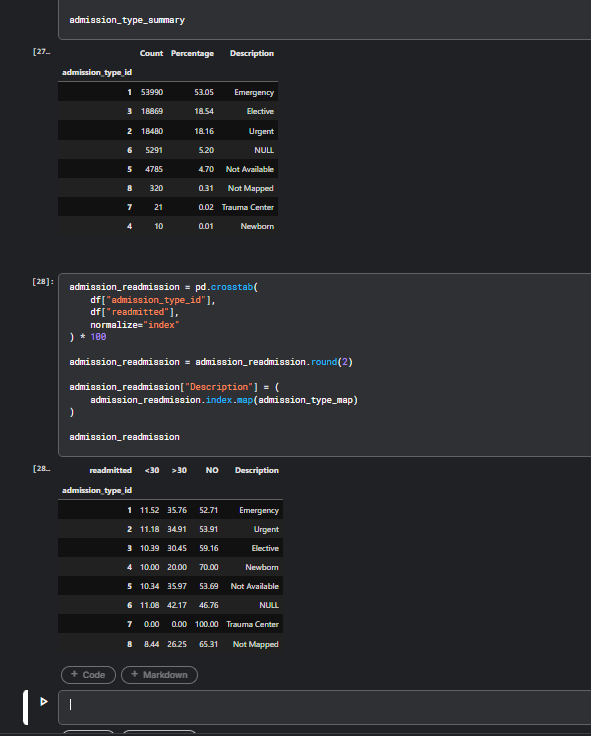
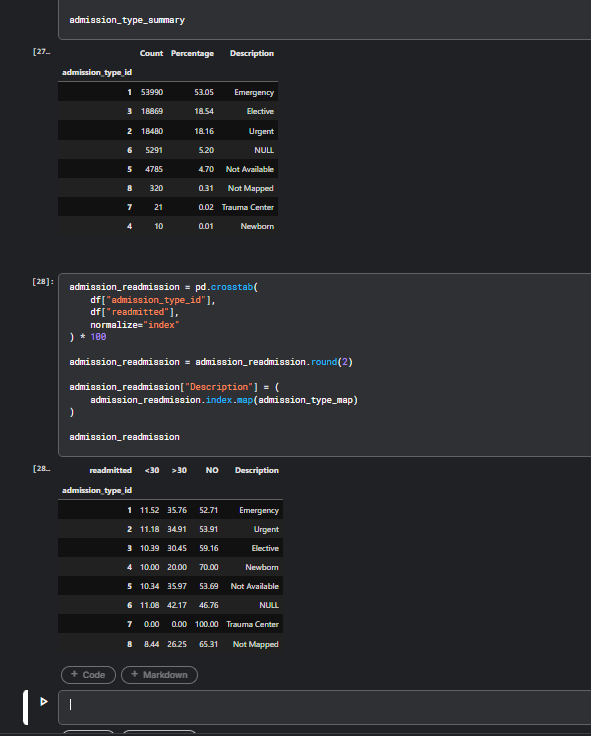

In [117]:
admission_source_counts = df["admission_source_id"].value_counts()

admission_source_summary = pd.DataFrame({
    "Count": admission_source_counts,
    "Percentage": (
        admission_source_counts / len(df) * 100
    ).round(2)
})

admission_source_summary["Description"] = (
    admission_source_summary.index.map(admission_source_map)
)

admission_source_summary

,Count,Percentage,Description
admission_source_id,,,
7,57494,56.50,Emergency Room
1,29565,29.05,Physician Referral
17,6781,6.66,NULL
4,3187,3.13,Transfer from hospital
6,2264,2.22,Transfer from health care facility
2,1104,1.08,Clinic Referral
5,855,0.84,Transfer from SNF
3,187,0.18,HMO Referral
20,161,0.16,Not Mapped


In [118]:
source_readmission = pd.crosstab(
    df["admission_source_id"],
    df["readmitted"],
    normalize="index"
) * 100

source_readmission = source_readmission.round(2)

source_readmission["Description"] = (
    source_readmission.index.map(admission_source_map)
)

source_readmission

readmitted,<30,>30,NO,Description
admission_source_id,,,,
1,10.59,32.61,56.81,Physician Referral
2,10.05,28.08,61.87,Clinic Referral
3,15.51,31.02,53.48,HMO Referral
4,9.70,21.09,69.22,Transfer from hospital
5,11.81,27.60,60.58,Transfer from SNF
6,9.36,17.58,73.06,Transfer from health care facility
7,11.69,37.69,50.63,Emergency Room
8,12.50,25.00,62.50,Court/Law Enforcement
9,10.40,12.80,76.80,Not Available


### 2.14 Admission Source and Readmission

The majority of hospital encounters originated from two admission sources:

- Emergency Room: **56.50%**
- Physician Referral: **29.05%**

Together, these two sources account for more than 85% of all encounters.

Early readmission rates differ moderately across the major admission sources. For example:

- Emergency Room: **11.69%**
- Physician Referral: **10.59%**
- Clinic Referral: **10.05%**
- Transfer from hospital: **9.70%**
- Transfer from SNF: **11.01%**

Some rare admission-source categories show larger percentages, but their sample sizes are too small for reliable interpretation.

`admission_source_id` will therefore be retained as a categorical candidate feature.
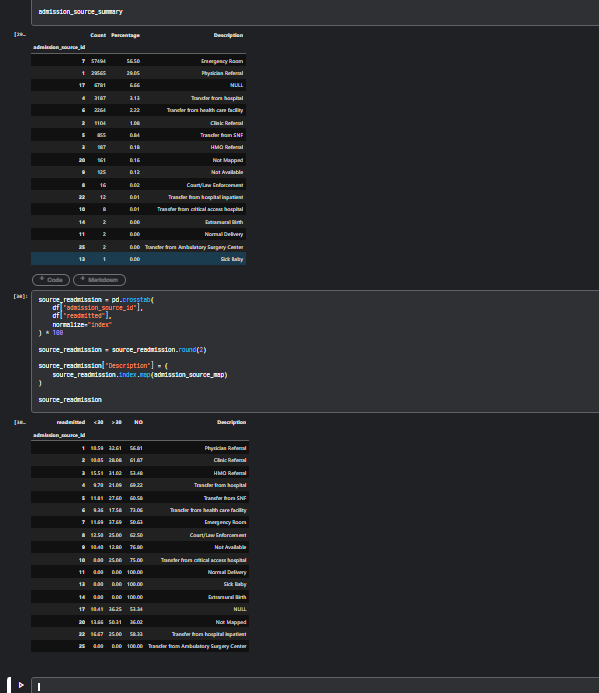

In [119]:
utilization_columns = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

utilization_summary = []

for column in utilization_columns:
    
    utilization_summary.append({
        "Feature": column,
        "Mean": df[column].mean(),
        "Median": df[column].median(),
        "Maximum": df[column].max(),
        "Zero Count": (df[column] == 0).sum(),
        "Zero Percentage": (
            (df[column] == 0).mean() * 100
        )
    })

utilization_summary = pd.DataFrame(utilization_summary)

utilization_summary.round(2)

,Feature,Mean,Median,Maximum,Zero Count,Zero Percentage
0,number_outpatient,0.37,0.0,42,85027,83.55
1,number_emergency,0.20,0.0,76,90383,88.81
2,number_inpatient,0.64,0.0,21,67630,66.46


### 2.15 Previous Healthcare Utilization

Previous healthcare utilization variables show strongly right-skewed distributions.

- 83.55% of encounters have no recorded outpatient visits in the previous year.
- 88.81% have no emergency visits.
- 66.46% have no previous inpatient admissions.

Although the median is zero for all three variables, a small number of patients have substantially higher utilization.

This suggests that prior healthcare utilization may contain useful information for identifying patients with recurrent healthcare needs.

In [120]:
utilization_columns = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

for column in utilization_columns:

    groups = pd.cut(
        df[column],
        bins=[-1, 0, 1, 2, 3, float("inf")],
        labels=["0", "1", "2", "3", "4+"]
    )

    summary = pd.DataFrame({
        "Count": groups.value_counts(sort=False),
        "Early Readmission Rate (%)":
            df["readmitted"].eq("<30")
              .groupby(groups, observed=False)
              .mean()
              .mul(100)
              .round(2)
    })

    print(f"\n{column}")
    display(summary)


number_outpatient


,Count,Early Readmission Rate (%)
number_outpatient,,
0,85027,10.67
1,8547,13.92
2,3594,13.75
3,2042,12.29
4+,2556,13.54



number_emergency


,Count,Early Readmission Rate (%)
number_emergency,,
0,90383,10.47
1,7677,14.35
2,2042,18.27
3,725,20.28
4+,939,28.54



number_inpatient


,Count,Early Readmission Rate (%)
number_inpatient,,
0,67630,8.44
1,19521,12.92
2,7566,17.43
3,3411,20.29
4+,3638,30.70


### 2.17 Healthcare Utilization and Early Readmission

Previous healthcare utilization shows different relationships with early readmission.

#### Previous Inpatient Admissions

A strong monotonic relationship is observed:

- 0 visits: 8.44%
- 1 visit: 12.92%
- 2 visits: 17.43%
- 3 visits: 20.29%
- 4+ visits: 30.70%

#### Previous Emergency Visits

A similarly strong pattern is observed:

- 0 visits: 10.47%
- 1 visit: 14.35%
- 2 visits: 18.27%
- 3 visits: 20.28%
- 4+ visits: 28.54%

#### Previous Outpatient Visits

The relationship is weaker and less monotonic:

- 0 visits: 10.67%
- 1 visit: 13.92%
- 2 visits: 13.75%
- 3 visits: 12.29%
- 4+ visits: 13.54%

Overall, previous inpatient and emergency utilization appear to be particularly informative candidate predictors of early readmission. These associations are descriptive and should not be interpreted as causal.

In [121]:
encounter_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

df[encounter_features].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

,mean,std,min,25%,50%,75%,max
time_in_hospital,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_diagnoses,7.42,1.93,1.0,6.0,8.0,9.0,16.0


### 2.18 Current Encounter Characteristics

The current hospitalization characteristics provide information about encounter complexity and patient condition.

Summary statistics show:

- Hospital stay duration has a median of 4 days with a maximum of 14 days.
- Laboratory procedures vary substantially, suggesting differences in diagnostic intensity.
- Medication counts show considerable variability, with some encounters involving a high number of medications.
- The number of diagnoses indicates that many patients have multiple recorded conditions.

These variables represent aspects of hospitalization complexity and may contribute to predicting early readmission risk.

In [122]:
encounter_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

for column in encounter_features:

    grouped = pd.qcut(
        df[column],
        q=5,
        duplicates="drop"
    )

    summary = pd.DataFrame({
        "Count": grouped.value_counts(sort=False),
        "Early Readmission Rate (%)":
            df["readmitted"].eq("<30")
            .groupby(grouped, observed=False)
            .mean()
            .mul(100)
            .round(2)
    })

    print(f"\n{column}")
    display(summary)


time_in_hospital


,Count,Early Readmission Rate (%)
time_in_hospital,,
"(0.999, 2.0]",31432,9.14
"(2.0, 3.0]",17756,10.67
"(3.0, 4.0]",13924,11.81
"(4.0, 7.0]",23364,12.41
"(7.0, 14.0]",15290,13.37



num_lab_procedures


,Count,Early Readmission Rate (%)
num_lab_procedures,,
"(0.999, 27.0]",20459,9.87
"(27.0, 40.0]",21826,10.87
"(40.0, 49.0]",20325,11.52
"(49.0, 60.0]",19741,11.69
"(60.0, 132.0]",19415,11.92



num_procedures


,Count,Early Readmission Rate (%)
num_procedures,,
"(-0.001, 1.0]",67394,11.43
"(1.0, 3.0]",22160,10.97
"(3.0, 6.0]",12212,10.04



num_medications


,Count,Early Readmission Rate (%)
num_medications,,
"(0.999, 9.0]",20515,8.83
"(9.0, 13.0]",23231,10.55
"(13.0, 17.0]",21848,11.49
"(17.0, 22.0]",18390,12.71
"(22.0, 81.0]",17782,12.64



number_diagnoses


,Count,Early Readmission Rate (%)
number_diagnoses,,
"(0.999, 5.0]",21007,8.49
"(5.0, 7.0]",20554,10.59
"(7.0, 9.0]",60090,12.28
"(9.0, 16.0]",115,14.78


### 2.19 Current Encounter Features and Early Readmission

The relationship between current hospitalization characteristics and early readmission was investigated using quantile-based analysis.

Key observations:

- `time_in_hospital` shows limited variation in early readmission rates across groups.
- `num_lab_procedures` does not demonstrate a strong monotonic relationship.
- `num_procedures` appears to have a weaker association with early readmission.
- `num_medications` shows a moderate increase in readmission risk among higher-utilization groups.
- `number_diagnoses` demonstrates a clearer relationship, suggesting that patients with more recorded diagnoses may have higher readmission risk.

Overall, these variables represent encounter complexity and patient condition severity and will be retained as candidate predictors.

In [123]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

correlation = df[numeric_features].corr()

correlation.round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.00,0.32,0.19,0.47,-0.01,-0.01,0.07,0.22
num_lab_procedures,0.32,1.00,0.06,0.27,-0.01,-0.00,0.04,0.15
num_procedures,0.19,0.06,1.00,0.39,-0.02,-0.04,-0.07,0.07
num_medications,0.47,0.27,0.39,1.00,0.05,0.01,0.06,0.26
number_outpatient,-0.01,-0.01,-0.02,0.05,1.00,0.09,0.11,0.09
number_emergency,-0.01,-0.00,-0.04,0.01,0.09,1.00,0.27,0.06
number_inpatient,0.07,0.04,-0.07,0.06,0.11,0.27,1.00,0.10
number_diagnoses,0.22,0.15,0.07,0.26,0.09,0.06,0.10,1.00


### 2.20 Numerical Feature Correlation Analysis

Correlation analysis was performed to identify highly correlated numerical variables and potential redundancy.

The highest observed correlations were:

- `time_in_hospital` and `num_medications`: 0.47
- `num_procedures` and `num_medications`: 0.39
- `time_in_hospital` and `num_lab_procedures`: 0.32

All correlations remained below levels associated with severe multicollinearity.

Healthcare utilization variables also showed relatively low correlations, suggesting that:

- `number_inpatient`
- `number_emergency`
- `number_outpatient`

capture different aspects of previous healthcare usage.

Therefore, all investigated numerical features will be retained as candidate predictors.

In [ ]:
# Create modeling dataset
df_model = df.copy()

print("Original shape:", df_model.shape)


In [ ]:
# Remove identifier / unusable columns
id_columns = [
    "encounter_id",
    "patient_nbr",
    "weight"
]

print(df_model[id_columns].nunique())

df_model = df_model.drop(columns=id_columns)

print("After removing identifiers:", df_model.shape)


## 3.2 Target Variable Transformation

The original `readmitted` variable contains three categories:

- `<30`: early readmission
- `>30`: readmission after 30 days
- `NO`: no readmission

The problem is converted into binary classification:

- `<30` → 1
- `>30` and `NO` → 0


In [ ]:
# Create binary target
df_model["readmitted_binary"] = (
    df_model["readmitted"]
    .apply(lambda x: 1 if x == "<30" else 0)
)

print(df_model["readmitted_binary"].value_counts())

# Remove original target
df_model = df_model.drop(columns=["readmitted"])

print(df_model.shape)


## 3.3 Missing Value Handling

Missing categorical values are replaced with an explicit `Unknown` category.

This preserves the possible information contained in missingness.


In [ ]:
missing_columns = [
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code",
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

# Replace question marks with missing values
df_model = df_model.replace("?", None)

print(df_model[missing_columns].isnull().sum())


In [ ]:
for col in missing_columns:
    df_model[col] = df_model[col].fillna("Unknown")

print(df_model[missing_columns].isnull().sum())


## 3.4 Feature Engineering

Additional features are created to capture patient complexity and treatment patterns.


In [ ]:
# Medication change indicator
df_model["medication_change_flag"] = (
    df_model["change"]
    .astype(str)
    .apply(lambda x: 1 if x == "Ch" else 0)
)

# Diabetes medication usage indicator
df_model["diabetes_medication_flag"] = (
    df_model["diabetesMed"]
    .astype(str)
    .apply(lambda x: 1 if x == "Yes" else 0)
)

print(df_model.shape)


## 3.5 Final Modeling Dataset

Prepare features and target for machine learning models.


In [ ]:
X = df_model.drop(columns=["readmitted_binary"])
y = df_model["readmitted_binary"]

print(X.shape)
print(y.value_counts())


# Phase 4 — Data Preparation and Modeling

This phase prepares the dataset for machine learning:
- categorical encoding
- train/test split
- preprocessing pipeline
- baseline classification models


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


In [ ]:
X = df_model.drop(columns=["readmitted_binary"])
y = df_model["readmitted_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


In [ ]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", len(categorical_features))
print("Numeric:", len(numeric_features))


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# Phase 5 — Baseline Models

Two baseline models are trained:
- Logistic Regression
- Random Forest

Class weighting is used because the target is imbalanced.


In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))


In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))


In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.title("ROC Curve - Random Forest")
plt.show()


In [ ]:
print("Confusion Matrix - Random Forest")
confusion_matrix(y_test, rf_pred)


# Phase 6 — Conclusion

The project followed the CRISP-DM methodology.

Main findings:
- Previous inpatient admissions were strongly associated with early readmission.
- Emergency utilization also showed predictive value.
- Missing information was preserved using explicit Unknown categories.
- The target variable was transformed into a binary early-readmission problem.
- Class imbalance was addressed using class weighting.

The final models provide a baseline framework for predicting 30-day hospital readmission risk.


# Advanced Modeling Extensions

This section upgrades the baseline project with:

- SMOTE imbalance handling
- XGBoost model
- Model comparison
- Feature importance
- SHAP explainability
- Hyperparameter tuning


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


## SMOTE Training Data

SMOTE is applied only on the training data to avoid information leakage.


In [ ]:
# Prepare transformed training data for SMOTE

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())


## XGBoost Model


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

xgb_pred = xgb_model.predict(X_test_processed)
xgb_prob = xgb_model.predict_proba(X_test_processed)[:,1]

print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))


## Model Comparison


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost + SMOTE"
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.sort_values(
    "ROC-AUC",
    ascending=False
)


## Hyperparameter Tuning

Randomized search is used to improve the XGBoost configuration.


In [ ]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1]
}

search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid,
    n_iter=5,
    scoring="roc_auc",
    cv=3,
    random_state=42
)

search.fit(
    X_train_smote,
    y_train_smote
)

print(search.best_params_)


## Feature Importance

Feature importance is extracted from the tuned XGBoost model to identify the most influential variables.


In [ ]:
import pandas as pd

feature_names = (
    preprocessor.get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": search.best_estimator_.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
).head(20)


## SHAP Explainability

SHAP provides local and global explanations of model predictions.


In [ ]:
# Optional SHAP analysis

try:
    import shap

    explainer = shap.TreeExplainer(
        search.best_estimator_
    )

    shap_values = explainer.shap_values(
        X_test_processed[:500]
    )

    shap.summary_plot(
        shap_values,
        X_test_processed[:500],
        feature_names=feature_names
    )

except Exception as e:
    print("Install SHAP if needed:", e)


# Final Project Conclusion

The project was extended from baseline classification into an explainable machine learning workflow.

Final components:

- CRISP-DM methodology
- Missing value strategy
- Feature engineering
- Class imbalance handling with SMOTE
- Ensemble learning with XGBoost
- Hyperparameter optimization
- Feature importance analysis
- SHAP explainability

The final system provides both predictive performance and interpretability for early hospital readmission prediction.
